# 🤖 Model Training — Best Configurations from Experiment Pipeline

This notebook trains models using the **best hyperparameters** found by our automated experiment pipeline (`run_experiment.py` + Optuna). No tuning is needed — we directly train with proven optimal configurations for three prediction horizons:

| Horizon | Target | Threshold | Best Model | Test ROC-AUC |
|---------|--------|-----------|------------|--------------|
| **1 week** | `alpha_1w` | 2% | CatBoost | **0.6110** |
| **1 month** | `alpha_1m` | 3% | CatBoost | **0.5695** |
| **3 months** | `alpha_3m` | 5% | LightGBM | **0.5640** |

## Workflow
1. Load data & configure all three horizons
2. Train each horizon's best model with known-optimal params
3. Evaluate: ROC-AUC, PR curves, confusion matrices, calibration
4. Backtest: simulate trading strategies at different probability thresholds
5. SHAP feature importance analysis
6. Save production-ready models

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, average_precision_score,
    precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve

# Gradient Boosting Classifiers
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Feature Importance
import shap

# Model persistence
import joblib
import json

# Visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(" Libraries imported successfully")

 Libraries imported successfully


---
## Part 1: Best Hyperparameters from Experiment Pipeline

These were found by `run_experiment.py` running 50 Optuna trials per model with 3-fold TimeSeriesSplit CV. We hardcode them here for fast, reproducible training.

In [2]:
# ──────────────────────────────────────────────────────────────────────
# Best hyperparameters per horizon (from experiment pipeline)
# ──────────────────────────────────────────────────────────────────────

EXPERIMENT_CONFIGS = {
    'alpha_1w': {
        'target_col': 'alpha_1w',
        'threshold': 0.02,
        'best_model': 'CatBoost',
        'test_roc_auc': 0.6110,
        'params': {
            'XGBoost': {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.0217, 'subsample': 0.7264, 'colsample_bytree': 0.8989, 'min_child_weight': 12, 'reg_alpha': 5.955, 'reg_lambda': 48.081, 'random_state': 42, 'n_jobs': -1, 'scale_pos_weight': 1.0},
            'LightGBM': {'n_estimators': 481, 'max_depth': 5, 'learning_rate': 0.0110, 'num_leaves': 12, 'subsample': 0.7112, 'colsample_bytree': 0.6471, 'min_child_samples': 28, 'reg_alpha': 0.729, 'reg_lambda': 24.161, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'},
            'CatBoost': {'iterations': 121, 'depth': 5, 'learning_rate': 0.0967, 'l2_leaf_reg': 17.522, 'border_count': 46, 'random_seed': 42, 'auto_class_weights': 'Balanced', 'verbose': False},
        }
    },
    'alpha_1m': {
        'target_col': 'alpha_1m',
        'threshold': 0.03,
        'best_model': 'CatBoost',
        'test_roc_auc': 0.5695,
        'params': {
            'XGBoost': {'n_estimators': 322, 'max_depth': 6, 'learning_rate': 0.0155, 'subsample': 0.8623, 'colsample_bytree': 0.8740, 'min_child_weight': 12, 'reg_alpha': 3.069, 'reg_lambda': 30.440, 'random_state': 42, 'n_jobs': -1, 'scale_pos_weight': 1.0},
            'LightGBM': {'n_estimators': 358, 'max_depth': 4, 'learning_rate': 0.0242, 'num_leaves': 14, 'subsample': 0.8989, 'colsample_bytree': 0.6980, 'min_child_samples': 42, 'reg_alpha': 1.247, 'reg_lambda': 2.100, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'},
            'CatBoost': {'iterations': 177, 'depth': 6, 'learning_rate': 0.0901, 'l2_leaf_reg': 2.653, 'border_count': 62, 'random_seed': 42, 'auto_class_weights': 'Balanced', 'verbose': False},
        }
    },
    'alpha_3m': {
        'target_col': 'alpha_3m',
        'threshold': 0.05,
        'best_model': 'LightGBM',
        'test_roc_auc': 0.5640,
        'params': {
            'XGBoost': {'n_estimators': 409, 'max_depth': 5, 'learning_rate': 0.0168, 'subsample': 0.7037, 'colsample_bytree': 0.8598, 'min_child_weight': 15, 'reg_alpha': 3.930, 'reg_lambda': 44.750, 'random_state': 42, 'n_jobs': -1, 'scale_pos_weight': 1.0},
            'LightGBM': {'n_estimators': 362, 'max_depth': 4, 'learning_rate': 0.0112, 'num_leaves': 37, 'subsample': 0.6107, 'colsample_bytree': 0.8045, 'min_child_samples': 10, 'reg_alpha': 1.373, 'reg_lambda': 1.006, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'},
            'CatBoost': {'iterations': 391, 'depth': 6, 'learning_rate': 0.0575, 'l2_leaf_reg': 24.141, 'border_count': 55, 'random_seed': 42, 'auto_class_weights': 'Balanced', 'verbose': False},
        }
    },
}

# Feature definitions
NUMERICAL_COLS = [
    'role_bucket', 'log_transaction_value', 'delta_owned', 'owned_pct_change',
    'insider_trade_count', 'days_since_last_trade', 'reporting_lag',
    'cluster_buy', 'cluster_c_level_pct', 'log_market_cap',
    'price_range_position', 'volatility_30d'
]
CATEGORICAL_COLS = ['sector']
FEATURE_COLS_ENCODED = NUMERICAL_COLS + ['sector_encoded']
FEATURE_COLS_CAT = NUMERICAL_COLS + ['sector']

# ──────────────────────────────────────────────────────────────────────
# SELECT WHICH HORIZON TO TRAIN (change this to switch)
# ──────────────────────────────────────────────────────────────────────
ACTIVE_HORIZON = 'alpha_3m'  # Options: 'alpha_1w', 'alpha_1m', 'alpha_3m'

cfg = EXPERIMENT_CONFIGS[ACTIVE_HORIZON]
ALPHA_THRESHOLD = cfg['threshold']
TARGET_COL = cfg['target_col']

print(f"🎯 Active horizon: {ACTIVE_HORIZON}")
print(f"   Target: {TARGET_COL} > {ALPHA_THRESHOLD*100:.0f}%")
print(f"   Best model from experiments: {cfg['best_model']} (ROC-AUC {cfg['test_roc_auc']:.4f})")

🎯 Active horizon: alpha_3m
   Target: alpha_3m > 5%
   Best model from experiments: LightGBM (ROC-AUC 0.5640)


---
## Part 2: Data Loading, Target Engineering & Splitting

In [3]:
# Load dataset
project_root = Path.cwd().parent.parent
data_path = project_root / "data" / "processed" / "insider_trades_ml_ready.parquet"
df = pd.read_parquet(data_path)

# Create binary target
df['target_class'] = (df[TARGET_COL] > ALPHA_THRESHOLD).astype(int)
df_model = df[df[TARGET_COL].notna()].copy()

# Class balance
class_dist = df_model['target_class'].value_counts(normalize=True)
positive_rate = class_dist.get(1, 0)
scale_pos_weight = (1 - positive_rate) / positive_rate if positive_rate < 0.30 else 1.0

print(f"📊 Dataset: {len(df_model):,} rows")
print(f"   Class 1 ({TARGET_COL} > {ALPHA_THRESHOLD*100:.0f}%): {positive_rate*100:.1f}%")
print(f"   scale_pos_weight: {scale_pos_weight:.2f}")

📊 Dataset: 39,393 rows
   Class 1 (alpha_3m > 5%): 37.2%
   scale_pos_weight: 1.00


In [4]:
# Impute missing values
df_model['sector'] = df_model['sector'].fillna('Unknown')
df_model['price_range_position'] = df_model['price_range_position'].fillna(0.5)
df_model['volatility_30d'] = df_model['volatility_30d'].fillna(df_model['volatility_30d'].median())
df_model['days_since_last_trade'] = df_model['days_since_last_trade'].fillna(-1)
for col in df_model.select_dtypes(include=[np.number]).columns:
    if df_model[col].isna().sum() > 0:
        df_model[col] = df_model[col].fillna(df_model[col].median())

# Temporal split
TRAIN_END_DATE = '2023-12-31'
TEST_START_DATE = '2024-01-01'
df_model['filing_date'] = pd.to_datetime(df_model['filing_date'])
df_train = df_model[df_model['filing_date'] <= TRAIN_END_DATE].copy()
df_test = df_model[df_model['filing_date'] >= TEST_START_DATE].copy()

# Encode sector
le_sector = LabelEncoder()
df_train['sector_encoded'] = le_sector.fit_transform(df_train['sector'])
df_test['sector_encoded'] = le_sector.transform(
    df_test['sector'].apply(lambda x: x if x in le_sector.classes_ else 'Unknown')
)

# Prepare feature matrices
X_train = df_train[FEATURE_COLS_ENCODED].copy()
y_train = df_train['target_class'].copy()
X_test = df_test[FEATURE_COLS_ENCODED].copy()
y_test = df_test['target_class'].copy()

# CatBoost native categorical features
X_train_cat = df_train[FEATURE_COLS_CAT].copy()
X_test_cat = df_test[FEATURE_COLS_CAT].copy()

# Metadata for backtesting
test_metadata = df_test[['ticker', 'filing_date', TARGET_COL, 'target_class']].copy()

print(f"✅ Data ready:")
print(f"   Train: {len(X_train):,} rows ({df_train['filing_date'].min().date()} → {df_train['filing_date'].max().date()})")
print(f"   Test:  {len(X_test):,} rows ({df_test['filing_date'].min().date()} → {df_test['filing_date'].max().date()})")
print(f"   Features: {len(FEATURE_COLS_ENCODED)} ({len(NUMERICAL_COLS)} numerical + 1 encoded categorical)")

✅ Data ready:
   Train: 31,620 rows (2018-01-02 → 2023-12-29)
   Test:  7,773 rows (2024-01-02 → 2025-11-06)
   Features: 13 (12 numerical + 1 encoded categorical)


---
## Part 3: Train All Models with Best Hyperparameters

No Optuna search needed — we use the optimal parameters found by the experiment pipeline.

In [5]:
# Train XGBoost
print("🔹 Training XGBoost with optimal params...")
xgb_model = xgb.XGBClassifier(**cfg['params']['XGBoost'])
xgb_model.fit(X_train, y_train)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
ap_xgb = average_precision_score(y_test, y_pred_proba_xgb)
print(f"   ROC-AUC: {auc_xgb:.4f}  |  Avg Precision: {ap_xgb:.4f}")

# Train LightGBM
print("\n🔹 Training LightGBM with optimal params...")
lgb_model = lgb.LGBMClassifier(**cfg['params']['LightGBM'])
lgb_model.fit(X_train, y_train)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb = lgb_model.predict(X_test)
auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
ap_lgb = average_precision_score(y_test, y_pred_proba_lgb)
print(f"   ROC-AUC: {auc_lgb:.4f}  |  Avg Precision: {ap_lgb:.4f}")

# Train CatBoost
print("\n🔹 Training CatBoost with optimal params...")
cat_model = CatBoostClassifier(**cfg['params']['CatBoost'])
cat_model.fit(X_train_cat, y_train, cat_features=['sector'], verbose=False)
y_pred_proba_cat = cat_model.predict_proba(X_test_cat)[:, 1]
y_pred_cat = cat_model.predict(X_test_cat)
auc_cat = roc_auc_score(y_test, y_pred_proba_cat)
ap_cat = average_precision_score(y_test, y_pred_proba_cat)
print(f"   ROC-AUC: {auc_cat:.4f}  |  Avg Precision: {ap_cat:.4f}")

print("\n✅ All models trained.")

🔹 Training XGBoost with optimal params...
   ROC-AUC: 0.5608  |  Avg Precision: 0.3859

🔹 Training LightGBM with optimal params...
[LightGBM] [Info] Number of positive: 11962, number of negative: 19658
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2239
[LightGBM] [Info] Number of data points in the train set: 31620, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

---
## Part 4: Model Comparison

In [7]:
# Collect results
results = {
    'XGBoost': {'ROC-AUC': auc_xgb, 'Avg Precision': ap_xgb, 'predictions': y_pred_xgb, 'probabilities': y_pred_proba_xgb, 'model': xgb_model},
    'CatBoost': {'ROC-AUC': auc_cat, 'Avg Precision': ap_cat, 'predictions': y_pred_cat, 'probabilities': y_pred_proba_cat, 'model': cat_model},
    'LightGBM': {'ROC-AUC': auc_lgb, 'Avg Precision': ap_lgb, 'predictions': y_pred_lgb, 'probabilities': y_pred_proba_lgb, 'model': lgb_model},
}

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'ROC-AUC': [results[m]['ROC-AUC'] for m in results],
    'Avg Precision': [results[m]['Avg Precision'] for m in results]
}).sort_values('ROC-AUC', ascending=False)

best_model_name = comparison_df.iloc[0]['Model']

print(f"📊 Model Comparison ({ACTIVE_HORIZON}, threshold={ALPHA_THRESHOLD*100:.0f}%):")
print("=" * 50)
print(comparison_df.to_string(index=False))
print(f"\n🏆 Best Model: {best_model_name}")
print(f"\n📋 Classification Report ({best_model_name}):")
print(classification_report(y_test, results[best_model_name]['predictions'], target_names=['Skip', 'High Alpha']))

📊 Model Comparison (alpha_3m, threshold=5%):
   Model  ROC-AUC  Avg Precision
LightGBM 0.563316       0.393665
 XGBoost 0.560843       0.385907
CatBoost 0.560063       0.385772

🏆 Best Model: LightGBM

📋 Classification Report (LightGBM):
              precision    recall  f1-score   support

        Skip       0.71      0.37      0.49      5099
  High Alpha       0.37      0.70      0.49      2674

    accuracy                           0.49      7773
   macro avg       0.54      0.54      0.49      7773
weighted avg       0.59      0.49      0.49      7773



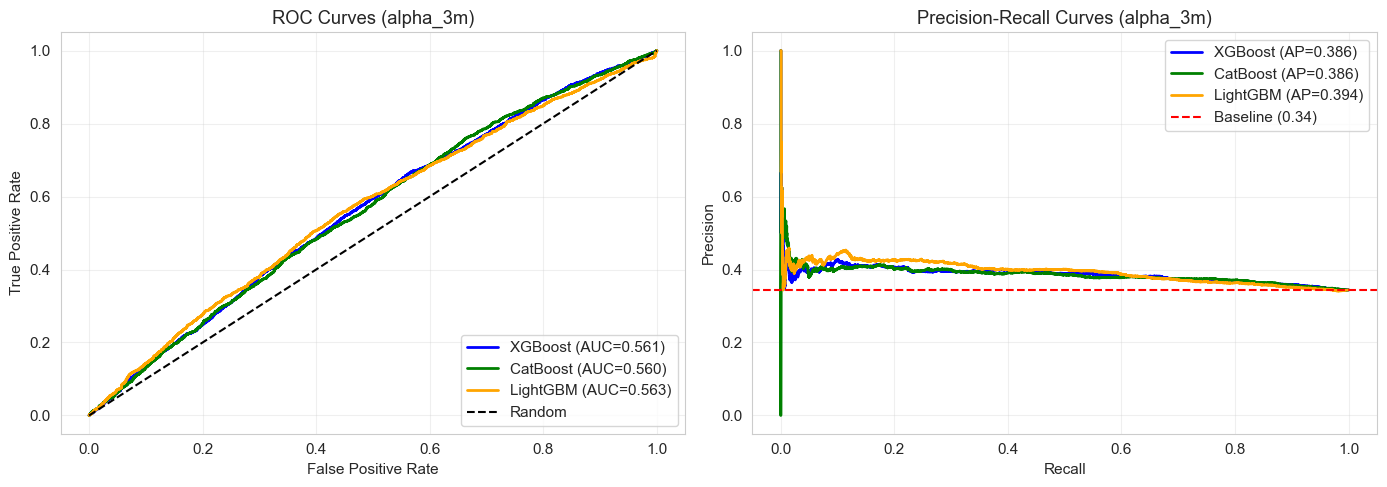

In [8]:
# ROC & Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
colors = ['blue', 'green', 'orange']
for (name, data), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, data['probabilities'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={data['ROC-AUC']:.3f})", color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curves ({ACTIVE_HORIZON})')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
for (name, data), color in zip(results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, data['probabilities'])
    axes[1].plot(recall, precision, label=f"{name} (AP={data['Avg Precision']:.3f})", color=color, linewidth=2)

# Add baseline (random)
baseline = y_test.mean()
axes[1].axhline(baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curves ({ACTIVE_HORIZON})')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 5: Confusion Matrix Analysis

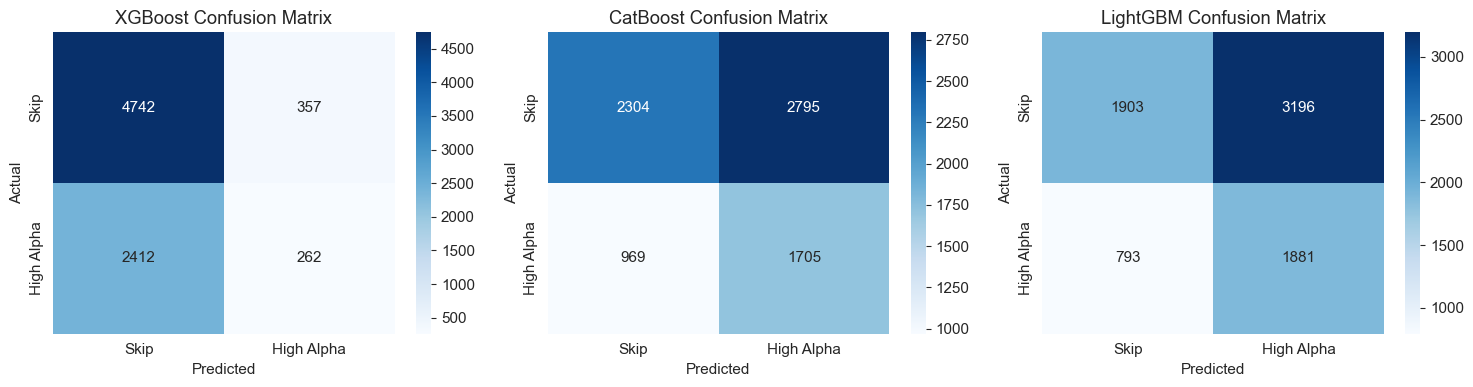

In [9]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, data) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, data['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Skip', 'High Alpha'],
                yticklabels=['Skip', 'High Alpha'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

---
## Part 6: Probability Calibration Analysis

**Key Question:** Do predicted probabilities match actual outcomes?

e.g., When the model predicts 80% probability, do ~80% of those trades actually have alpha > threshold?

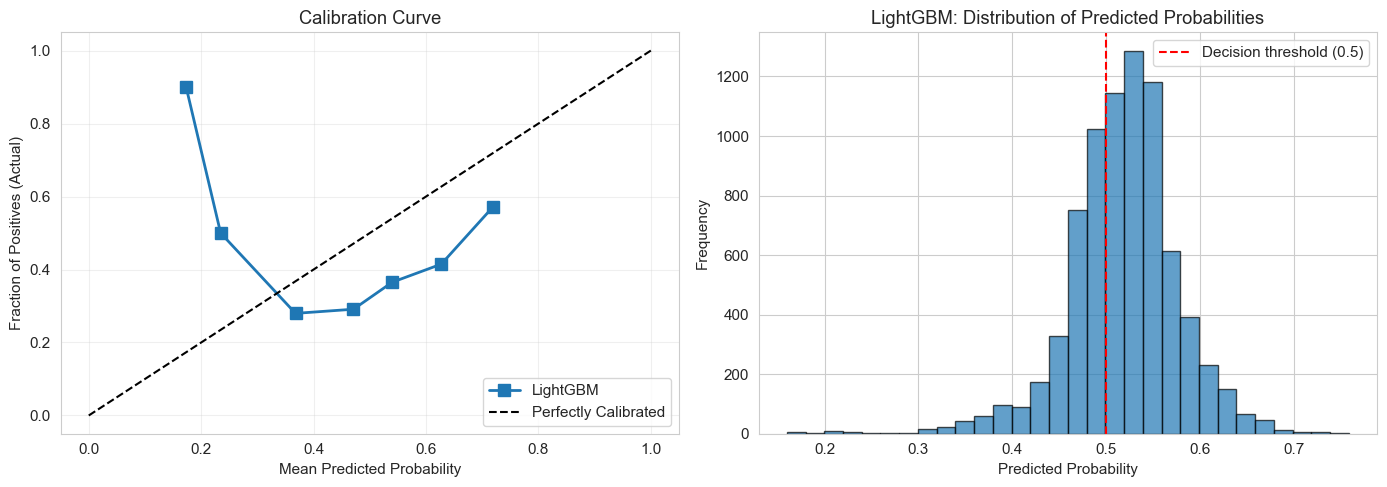

In [10]:
# Calibration curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve for best model
best_proba = results[best_model_name]['probabilities']
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, best_proba, n_bins=10)

axes[0].plot(mean_predicted_value, fraction_of_positives, 's-', label=best_model_name, linewidth=2, markersize=8)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives (Actual)')
axes[0].set_title('Calibration Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of predicted probabilities
axes[1].hist(best_proba, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0.5, color='red', linestyle='--', label='Decision threshold (0.5)')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'{best_model_name}: Distribution of Predicted Probabilities')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Part 7: THE KEY METRIC - Average Alpha by Probability Bin

**This is the real test:** Do trades with higher predicted probability actually generate more alpha?

In [11]:
def analyze_alpha_by_probability(y_proba, actual_alpha, n_bins=10):
    """
    Analyze actual alpha returns by predicted probability bin.
    """
    df_analysis = pd.DataFrame({
        'probability': y_proba,
        'actual_alpha': actual_alpha
    })
    
    # Create probability bins
    df_analysis['prob_bin'] = pd.qcut(df_analysis['probability'], q=n_bins, duplicates='drop')
    
    # Calculate stats per bin
    bin_stats = df_analysis.groupby('prob_bin').agg({
        'probability': ['mean', 'count'],
        'actual_alpha': ['mean', 'median', 'std']
    }).round(4)
    
    bin_stats.columns = ['avg_prob', 'n_samples', 'avg_alpha', 'median_alpha', 'std_alpha']
    bin_stats = bin_stats.reset_index()
    
    return bin_stats

In [12]:
# Analyze for best model
best_proba = results[best_model_name]['probabilities']
actual_alpha = test_metadata[TARGET_COL].values

alpha_by_prob = analyze_alpha_by_probability(best_proba, actual_alpha, n_bins=10)

print(f" {best_model_name}: Average Alpha by Probability Decile")
print("=" * 70)
for _, row in alpha_by_prob.iterrows():
    print(f"   Prob: {row['avg_prob']:.2f} | n={int(row['n_samples']):4d} | "
          f"Avg Alpha: {row['avg_alpha']*100:+6.2f}% | Median: {row['median_alpha']*100:+6.2f}%")

 LightGBM: Average Alpha by Probability Decile
   Prob: 0.41 | n= 778 | Avg Alpha:  -8.25% | Median:  -6.18%
   Prob: 0.47 | n= 777 | Avg Alpha:  -3.32% | Median:  -3.38%
   Prob: 0.49 | n= 777 | Avg Alpha:  -0.44% | Median:  -3.58%
   Prob: 0.50 | n= 777 | Avg Alpha:  -2.02% | Median:  -4.51%
   Prob: 0.51 | n= 778 | Avg Alpha:  -1.11% | Median:  -5.43%
   Prob: 0.53 | n= 777 | Avg Alpha:  +0.62% | Median:  -2.72%
   Prob: 0.54 | n= 777 | Avg Alpha:  +5.73% | Median:  -0.35%
   Prob: 0.55 | n= 777 | Avg Alpha:  +2.63% | Median:  -1.58%
   Prob: 0.57 | n= 777 | Avg Alpha:  +8.26% | Median:  +1.11%
   Prob: 0.62 | n= 778 | Avg Alpha: +10.07% | Median:  +0.11%


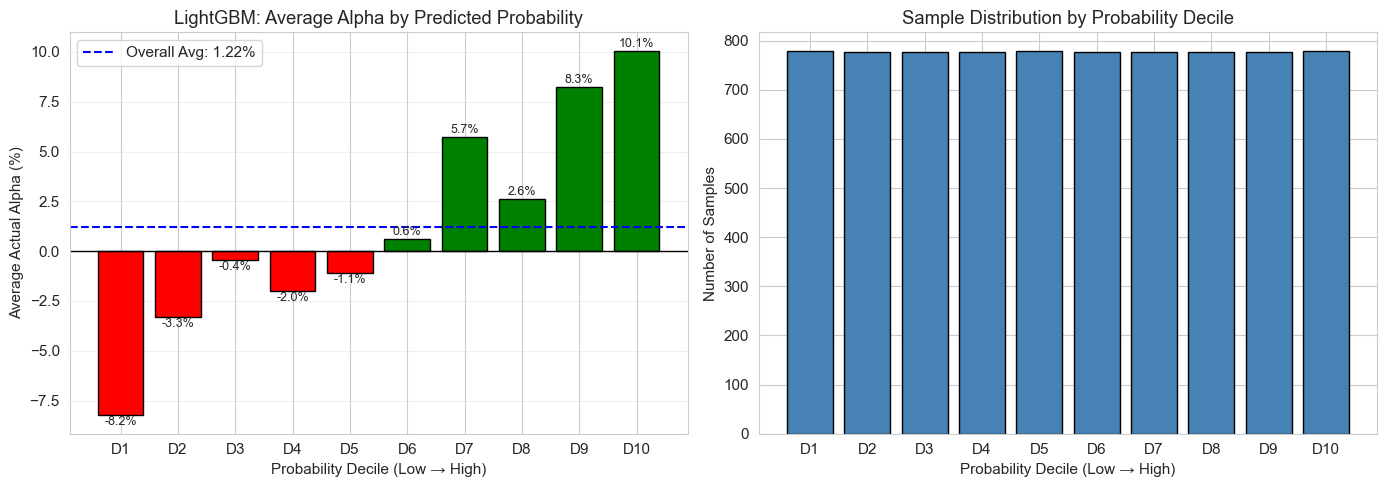

In [13]:
# Visualize Alpha by Probability Bin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average Alpha by Probability Bin
x = range(len(alpha_by_prob))
colors = ['red' if a < 0 else 'green' for a in alpha_by_prob['avg_alpha']]
bars = axes[0].bar(x, alpha_by_prob['avg_alpha'] * 100, color=colors, edgecolor='black')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].axhline(actual_alpha.mean() * 100, color='blue', linestyle='--', 
                label=f'Overall Avg: {actual_alpha.mean()*100:.2f}%')
axes[0].set_xlabel('Probability Decile (Low → High)')
axes[0].set_ylabel('Average Actual Alpha (%)')
axes[0].set_title(f'{best_model_name}: Average Alpha by Predicted Probability')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'D{i+1}' for i in range(len(alpha_by_prob))])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, alpha_by_prob['avg_alpha']):
    ypos = bar.get_height() + 0.2 if val >= 0 else bar.get_height() - 0.5
    axes[0].text(bar.get_x() + bar.get_width()/2, ypos, 
                 f'{val*100:.1f}%', ha='center', fontsize=9)

# Plot 2: Sample count per bin
axes[1].bar(x, alpha_by_prob['n_samples'], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Probability Decile (Low → High)')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Sample Distribution by Probability Decile')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'D{i+1}' for i in range(len(alpha_by_prob))])

plt.tight_layout()
plt.show()

In [14]:
# Top Decile vs Bottom Decile comparison (THE KEY RESULT)
top_decile_alpha = alpha_by_prob.iloc[-1]['avg_alpha'] * 100
bottom_decile_alpha = alpha_by_prob.iloc[0]['avg_alpha'] * 100
overall_alpha = actual_alpha.mean() * 100

print("\n" + "=" * 60)
print(" KEY RESULT: Top vs Bottom Decile")
print("=" * 60)
print(f"   Top Decile (Highest Prob):    {top_decile_alpha:+.2f}%")
print(f"   Bottom Decile (Lowest Prob):  {bottom_decile_alpha:+.2f}%")
print(f"   Overall Average:              {overall_alpha:+.2f}%")
print(f"\n   Spread (Top - Bottom):        {top_decile_alpha - bottom_decile_alpha:+.2f}%")
print(f"   Top Decile vs Average:        {top_decile_alpha - overall_alpha:+.2f}%")

if top_decile_alpha > bottom_decile_alpha:
    print("\n    Model successfully ranks trades - higher probability → higher alpha!")
else:
    print("\n     Model ranking is inverted - needs investigation")


 KEY RESULT: Top vs Bottom Decile
   Top Decile (Highest Prob):    +10.07%
   Bottom Decile (Lowest Prob):  -8.25%
   Overall Average:              +1.22%

   Spread (Top - Bottom):        +18.32%
   Top Decile vs Average:        +8.85%

    Model successfully ranks trades - higher probability → higher alpha!


---
## Part 8: Backtest - Trading Strategy Based on Probability Threshold

In [15]:
# Prepare backtest data
backtest_df = test_metadata.copy()
backtest_df['predicted_prob'] = results[best_model_name]['probabilities']
backtest_df = backtest_df.sort_values('filing_date').reset_index(drop=True)

print(f"  Backtest Data:")
print(f"   Period: {backtest_df['filing_date'].min().date()} to {backtest_df['filing_date'].max().date()}")
print(f"   Total trades: {len(backtest_df):,}")

  Backtest Data:
   Period: 2024-01-02 to 2025-11-06
   Total trades: 7,773


In [16]:
def backtest_probability_strategy(df, prob_threshold=0.5, min_trades_per_period=5):
    """
    Backtest a strategy that only takes trades with probability above threshold.
    """
    df = df.copy()
    df['period'] = df['filing_date'].dt.to_period('W')
    
    period_results = []
    
    for period, group in df.groupby('period'):
        # Filter by probability threshold
        high_prob = group[group['predicted_prob'] >= prob_threshold]
        
        if len(high_prob) >= min_trades_per_period:
            avg_alpha = high_prob[TARGET_COL].mean()
            period_results.append({
                'period': period,
                'n_trades': len(high_prob),
                'avg_alpha': avg_alpha,
                'avg_prob': high_prob['predicted_prob'].mean()
            })
    
    result_df = pd.DataFrame(period_results)
    if len(result_df) > 0:
        result_df['period_date'] = result_df['period'].apply(lambda x: x.to_timestamp())
        result_df['cumulative_return'] = (1 + result_df['avg_alpha']).cumprod() - 1
    
    return result_df

In [17]:
# Run backtest with different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6]
backtest_results = {}

print(" Backtest Results by Probability Threshold:")

for thresh in thresholds:
    bt = backtest_probability_strategy(backtest_df, prob_threshold=thresh, min_trades_per_period=3)
    if len(bt) > 0:
        backtest_results[thresh] = bt
        avg_alpha = bt['avg_alpha'].mean() * 100
        final_ret = bt['cumulative_return'].iloc[-1] * 100
        avg_trades = bt['n_trades'].mean()
        print(f"   Threshold ≥{thresh:.1f}: Avg Alpha={avg_alpha:+.2f}%, "
              f"Final Return={final_ret:+.1f}%, Avg Trades/Week={avg_trades:.1f}")

# Baseline (all trades)
baseline = backtest_probability_strategy(backtest_df, prob_threshold=0.0, min_trades_per_period=3)
backtest_results[0.0] = baseline
print(f"\n   Baseline (all): Avg Alpha={baseline['avg_alpha'].mean()*100:+.2f}%, "
      f"Final Return={baseline['cumulative_return'].iloc[-1]*100:+.1f}%")

 Backtest Results by Probability Threshold:
   Threshold ≥0.3: Avg Alpha=+1.74%, Final Return=+279.4%, Avg Trades/Week=79.8
   Threshold ≥0.4: Avg Alpha=+2.45%, Final Return=+610.1%, Avg Trades/Week=77.3
   Threshold ≥0.5: Avg Alpha=+4.61%, Final Return=+3960.3%, Avg Trades/Week=52.3
   Threshold ≥0.6: Avg Alpha=+11.00%, Final Return=+32024.5%, Avg Trades/Week=6.8

   Baseline (all): Avg Alpha=+1.74%, Final Return=+279.5%


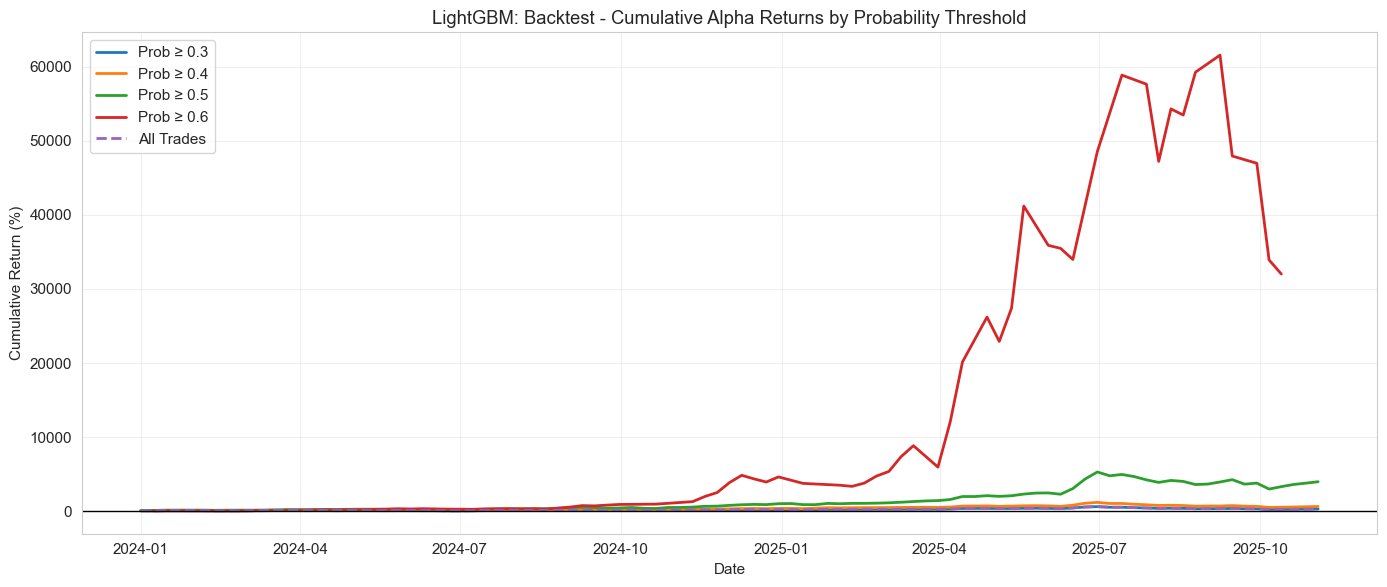

In [18]:
# Plot cumulative returns
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'0.0': 'gray', '0.3': 'blue', '0.4': 'green', '0.5': 'orange', '0.6': 'red'}

for thresh, bt in backtest_results.items():
    label = 'All Trades' if thresh == 0.0 else f'Prob ≥ {thresh}'
    style = '--' if thresh == 0.0 else '-'
    ax.plot(bt['period_date'], bt['cumulative_return'] * 100, 
            label=label, linewidth=2, linestyle=style)

ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title(f'{best_model_name}: Backtest - Cumulative Alpha Returns by Probability Threshold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 9: SHAP Feature Importance

In [19]:
# SHAP analysis on best model
print(f"🔍 Computing SHAP values for {best_model_name}...")

# Get the appropriate model and data
if best_model_name == 'CatBoost':
    explainer = shap.TreeExplainer(cat_model)
    X_for_shap = X_test_cat.sample(n=min(2000, len(X_test_cat)), random_state=RANDOM_STATE)
elif best_model_name == 'LightGBM':
    explainer = shap.TreeExplainer(lgb_model)
    X_for_shap = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)
else:
    explainer = shap.TreeExplainer(xgb_model)
    X_for_shap = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)

shap_values = explainer.shap_values(X_for_shap)
print(f" SHAP values computed")

🔍 Computing SHAP values for LightGBM...
 SHAP values computed


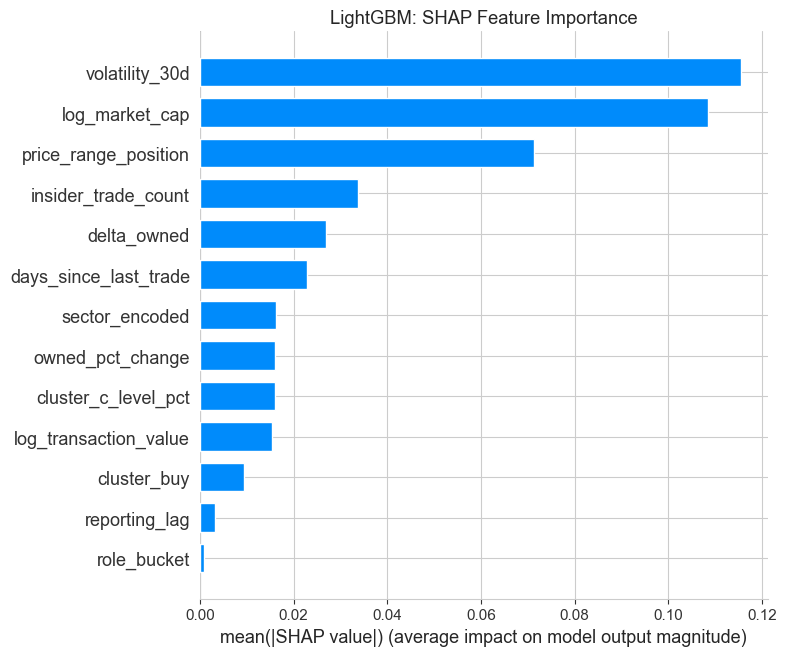

In [20]:
# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_for_shap, plot_type="bar", show=False)
plt.title(f"{best_model_name}: SHAP Feature Importance")
plt.tight_layout()
plt.show()

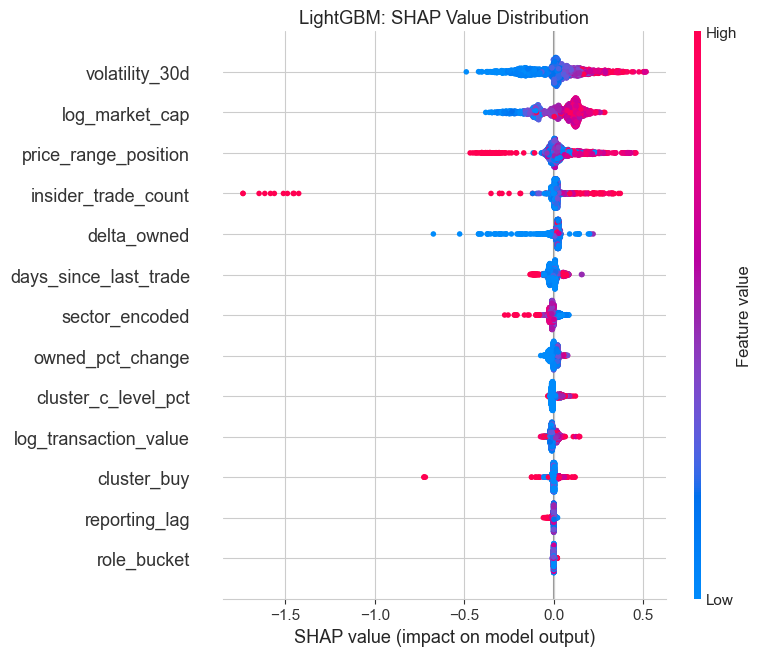

In [21]:
# Detailed SHAP plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_for_shap, show=False)
plt.title(f"{best_model_name}: SHAP Value Distribution")
plt.tight_layout()
plt.show()

---
## Part 10: Save Models and Summary

In [22]:
# Create output directory
model_output_dir = project_root / "src" / "models" / "saved_models"
model_output_dir.mkdir(parents=True, exist_ok=True)

# Save models
joblib.dump(xgb_model, model_output_dir / "xgb_classifier.joblib")
joblib.dump(lgb_model, model_output_dir / "lgb_classifier.joblib")
joblib.dump(cat_model, model_output_dir / "catboost_classifier.joblib")
joblib.dump(le_sector, model_output_dir / "sector_label_encoder.joblib")

# Save feature configuration
config = {
    'horizon': ACTIVE_HORIZON,
    'target_col': TARGET_COL,
    'target_threshold': ALPHA_THRESHOLD,
    'numerical_features': NUMERICAL_COLS,
    'categorical_features': CATEGORICAL_COLS,
    'feature_cols_encoded': FEATURE_COLS_ENCODED,
    'best_model': best_model_name,
    'best_roc_auc': results[best_model_name]['ROC-AUC'],
}

with open(model_output_dir / "feature_config.json", 'w') as f:
    json.dump(config, f, indent=2)

print(f"✅ Models saved to: {model_output_dir}")
print(f"   Horizon: {ACTIVE_HORIZON} | Best: {best_model_name} | ROC-AUC: {results[best_model_name]['ROC-AUC']:.4f}")

✅ Models saved to: /Users/andres.latorre/Documents/Stock-Market-Movement-Prediction-Through-Insider-Trading-and-Multi-Source-Financial-Data/src/models/saved_models
   Horizon: alpha_3m | Best: LightGBM | ROC-AUC: 0.5633


In [24]:
# Final Summary
print("\n" + "=" * 80)
print(f" FINAL SUMMARY — {ACTIVE_HORIZON.upper()} CLASSIFICATION")

print(f"\n📊 Dataset:")
print(f"   Train: {len(df_train):,} samples (2018-2023)")
print(f"   Test:  {len(df_test):,} samples (2024+)")
print(f"   Features: {len(FEATURE_COLS_ENCODED)}")
print(f"   Target: {TARGET_COL} > {ALPHA_THRESHOLD*100:.0f}% (Class 1)")

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   ROC-AUC: {results[best_model_name]['ROC-AUC']:.4f}")
print(f"   Avg Precision: {results[best_model_name]['Avg Precision']:.4f}")

print(f"\n📈 Key Insight: Alpha by Probability Decile")
print(f"   Top Decile Avg Alpha:    {top_decile_alpha:+.2f}%")
print(f"   Bottom Decile Avg Alpha: {bottom_decile_alpha:+.2f}%")
print(f"   Spread:                  {top_decile_alpha - bottom_decile_alpha:+.2f}%")

if len(backtest_results) > 0 and 0.5 in backtest_results:
    bt_05 = backtest_results[0.5]
    print(f"\n💰 Backtest (Prob ≥ 0.5):")
    print(f"   Avg Weekly Alpha: {bt_05['avg_alpha'].mean()*100:+.2f}%")
    print(f"   Cumulative Return: {bt_05['cumulative_return'].iloc[-1]*100:+.1f}%")

print("\n" + "=" * 80)


 FINAL SUMMARY — ALPHA_3M CLASSIFICATION

📊 Dataset:
   Train: 31,620 samples (2018-2023)
   Test:  7,773 samples (2024+)
   Features: 13
   Target: alpha_3m > 5% (Class 1)

🏆 Best Model: LightGBM
   ROC-AUC: 0.5633
   Avg Precision: 0.3937

📈 Key Insight: Alpha by Probability Decile
   Top Decile Avg Alpha:    +10.07%
   Bottom Decile Avg Alpha: -8.25%
   Spread:                  +18.32%

💰 Backtest (Prob ≥ 0.5):
   Avg Weekly Alpha: +4.61%
   Cumulative Return: +3960.3%



---
## 🎯 Conclusions

### Multi-Horizon Results
| Horizon | Threshold | Best Model | ROC-AUC |
|---------|-----------|------------|---------|
| 1 week  | 2%        | CatBoost   | 0.6110  |
| 1 month | 3%        | CatBoost   | 0.5695  |
| 3 months| 5%        | LightGBM   | 0.5640  |

### Why Classification Works
1. **Robust to outliers**: Extreme returns don't break the model
2. **Better signal extraction**: Focuses on patterns that predict "good" vs "bad" trades
3. **Actionable outputs**: Probability scores let us rank and filter trades

### How to Use
1. Set `ACTIVE_HORIZON` to your desired prediction window
2. Score insider trades with the trained classifier
3. Filter for trades with probability ≥ 0.5 (or your chosen threshold)
4. Top-decile trades should outperform the baseline

### Reproducing Results
Run experiment pipeline for full Optuna tuning:
```bash
python run_experiment.py --config configs/alpha_1w_baseline.yaml
```